In [24]:
library(spacexr)
library(Matrix)
### Load in/preprocess your data, this might vary based on your file type
#refdir <- system.file("extdata",'Reference/Vignette',package = 'spacexr') # directory for the reference
#counts <- read.csv(file.path(refdir,"dge.csv")) # load in counts matrix
counts <- read.csv("/data/work/MP/scRNA/RCTD/control/dge.csv")
rownames(counts) <- counts[,1]; counts[,1] <- NULL # Move first column to rownames
#supertype
meta_data <- read.csv("/data/work/MP/scRNA/RCTD/control/meta_data_control.csv") # load in meta_data (barcodes, clusters, and nUMI)

meta_data$barcode <- gsub("-", ".", meta_data$barcode)

cell_types <- meta_data$cluster; names(cell_types) <- meta_data$barcode # create cell_types named list
cell_types <- as.factor(cell_types) # convert to factor data type
nUMI <- meta_data$nUMI; names(nUMI) <- meta_data$barcode # create nUMI named list### Create the Reference object


In [25]:
non_neutrophil_barcodes <- names(cell_types)[cell_types != "Neutrophils"]

# fliter
counts_filtered <- counts[, non_neutrophil_barcodes]
cell_types_filtered <- cell_types[non_neutrophil_barcodes]
nUMI_filtered <- nUMI[non_neutrophil_barcodes]



Warning message in Reference(counts_filtered, cell_types_filtered, nUMI_filtered):
“Reference: missing cell types with no occurences:  Neutrophils”


In [27]:
# 2. 
cell_types_filtered <- droplevels(cell_types_filtered)  # 

# 3.
reference_filtered <- Reference(counts_filtered, cell_types_filtered, nUMI_filtered)

In [28]:
print(dim(reference_filtered@counts)) #observe Digital Gene Expression matrix
table(reference_filtered@cell_types) #number of occurences for each cell type
saveRDS(reference_filtered, '/data/work/MP/scRNA/RCTD/control/SCRef.rds')

[1] 18754 15975



          B cells Endothelial cells  Epithelial cells      Erythrocytes 
              467              5734              1545               185 
      Fibroblasts       Macrophages         Monocytes         Pericytes 
             4108               219               465              1517 
        Platelets           T cells 
              175              1560 

In [21]:
table(reference@cell_types)


          B cells Endothelial cells  Epithelial cells      Erythrocytes 
              467              5734              1545               185 
      Fibroblasts       Macrophages         Monocytes       Neutrophils 
             4108               219               465                 5 
        Pericytes         Platelets           T cells 
             1517               175              1560 

In [6]:
head(meta_data)

,barcode,cluster,nUMI
,<chr>,<chr>,<int>
1,AAACCCAAGAATGTTG.1,Epithelial cells,3413
2,AAACCCAAGCGGTAGT.1,Fibroblasts,2552
3,AAACCCAAGGGACAGG.1,Endothelial cells,1269
4,AAACCCAAGGTTCTAC.1,Endothelial cells,2402
5,AAACCCACAGATAAAC.1,T cells,1583
6,AAACCCACAGTAACGG.1,Fibroblasts,3425


In [4]:
head(counts)

,AAACCCAAGAATGTTG.1,AAACCCAAGCGGTAGT.1,AAACCCAAGGGACAGG.1,AAACCCAAGGTTCTAC.1,AAACCCACAGATAAAC.1,AAACCCACAGTAACGG.1,AAACCCACATGACAAA.1,AAACCCACATGACTGT.1,AAACCCAGTACTAAGA.1,AAACCCAGTAGATTGA.1,⋯,TTTGTTGCAGTGTGCC.1,TTTGTTGCATATCTCT.1,TTTGTTGGTACAACGG.1,TTTGTTGGTAGTCTTG.1,TTTGTTGGTGTAGTGG.1,TTTGTTGGTGTCGCTG.1,TTTGTTGTCAAGTCGT.1,TTTGTTGTCCGCTTAC.1,TTTGTTGTCGTTCGCT.1,TTTGTTGTCTTTCCAA.1
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC107308826,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
CARMIL3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC107305688,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC116652399,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GOLGB1,0,0,0,2,0,1,1,0,0,0,⋯,0,0,0,0,0,1,0,0,0,1
LOC107316499,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [15]:
counts <- read.csv("/data/work/MP/scRNA/RCTD/control/MappedDGEForR.csv") # load in counts matrix
coords <- read.csv("/data/work/MP/scRNA/RCTD/control/BeadLocationsForR.csv")

In [16]:
dim(coords)  
head(coords) 

[1] 2223    3

,barcodes,xcoord,ycoord
,<chr>,<int>,<int>
1,AAACAAGTATCTCCCA-1,50,102
2,AAACACCAATAACTGC-1,59,19
3,AAACAGCTTTCAGAAG-1,43,9
4,AAACAGGGTCTATATT-1,47,13
5,AAACCCGAACGAAATC-1,45,115
6,AAACCGGGTAGGTACC-1,42,28


In [17]:
coords$barcodes <- gsub("-", ".", coords$barcodes)
rownames(coords) <- coords$barcodes
coords$barcodes <- NULL

In [18]:
dim(coords)  
head(coords)

[1] 2223    2

,xcoord,ycoord
,<int>,<int>
AAACAAGTATCTCCCA.1,50,102
AAACACCAATAACTGC.1,59,19
AAACAGCTTTCAGAAG.1,43,9
AAACAGGGTCTATATT.1,47,13
AAACCCGAACGAAATC.1,45,115
AAACCGGGTAGGTACC.1,42,28


In [10]:
head(counts)

,AAACAAGTATCTCCCA.1,AAACACCAATAACTGC.1,AAACAGCTTTCAGAAG.1,AAACAGGGTCTATATT.1,AAACCCGAACGAAATC.1,AAACCGGGTAGGTACC.1,AAACCGTTCGTCCAGG.1,AAACCTCATGAAGTTG.1,AAACGAGACGGTTGAT.1,AAACTCGTGATATAAG.1,⋯,TTGTGGCCCTGACAGT.1,TTGTGGTAGGAGGGAT.1,TTGTGTATGCCACCAA.1,TTGTGTTTCCCGAAAG.1,TTGTTAGCAAATTCGA.1,TTGTTCAGTGTGCTAC.1,TTGTTGTGTGTCAAGA.1,TTGTTTCACATCCAGG.1,TTGTTTCATTAGTCTA.1,TTGTTTCCATACAACT.1
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC107308826,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
CARMIL3,0,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC107305688,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC116652826,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC107312337,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
LOC116652399,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


,xcoord,ycoord
,<int>,<int>
AAACAAGTATCTCCCA.1,50,102
AAACACCAATAACTGC.1,59,19
AAACAGCTTTCAGAAG.1,43,9
AAACAGGGTCTATATT.1,47,13
AAACCCGAACGAAATC.1,45,115
AAACCGGGTAGGTACC.1,42,28


[1] 20980  2223
                    x   y
AAACAAGTATCTCCCA.1 50 102
AAACACCAATAACTGC.1 59  19
AAACAGCTTTCAGAAG.1 43   9
AAACAGGGTCTATATT.1 47  13
AAACCCGAACGAAATC.1 45 115
AAACCGGGTAGGTACC.1 42  28


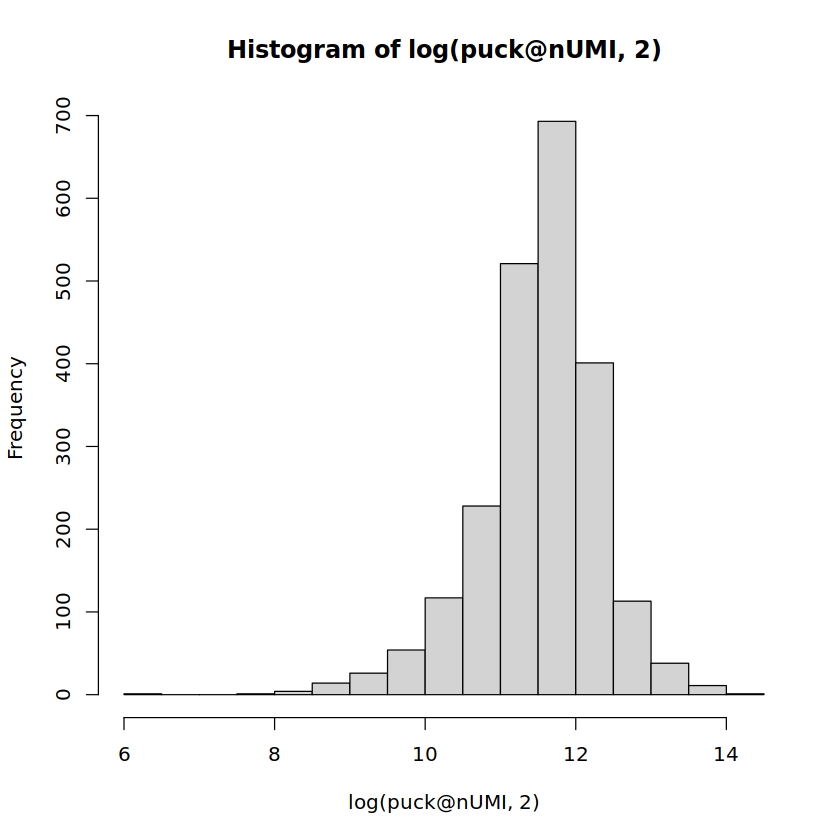

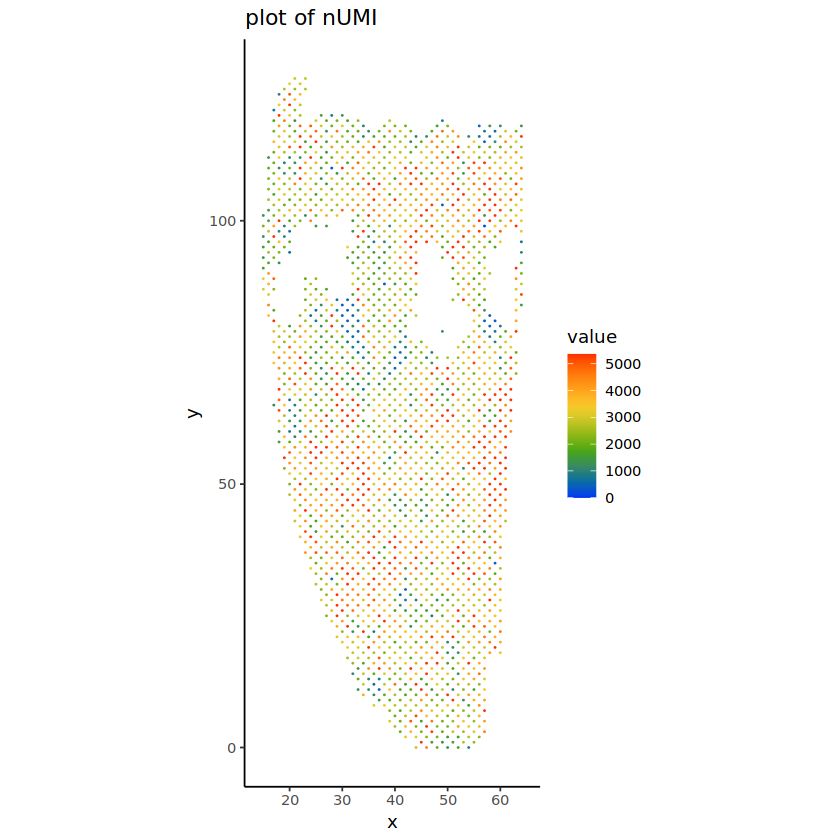

In [19]:
head(coords)
rownames(counts) <- counts[,1]
counts[,1] <- NULL
nUMI <- colSums(counts) # In this case, total counts per pixel is nUMI### Create SpatialRNA object
puck <- SpatialRNA(coords, counts, nUMI)
print(dim(puck@counts)) # observe Digital Gene Expression matrix
hist(log(puck@nUMI,2)) # histogram of log_2 nUMI
print(head(puck@coords)) # start of coordinate data.frame
barcodes <- colnames(puck@counts) # pixels to be used (a list of barcode names). # This list can be restricted if you want to crop the puck e.g. # puck <- restrict_puck(puck, barcodes) provides a basic plot of the nUMI of each pixel# on the plot:
plot_puck_continuous(puck, barcodes, puck@nUMI, ylimit = c(0,round(quantile(puck@nUMI,0.9))), 
                     title ='plot of nUMI')

In [29]:
#run RCTD
myRCTD <- create.RCTD(puck, reference_filtered, max_cores = 8)
myRCTD <- run.RCTD(myRCTD, doublet_mode = 'full')
results <- myRCTD@results

Begin: process_cell_type_info

process_cell_type_info: number of cells in reference: 15975

process_cell_type_info: number of genes in reference: 18754




          B cells Endothelial cells  Epithelial cells      Erythrocytes 
              467              5734              1545               185 
      Fibroblasts       Macrophages         Monocytes         Pericytes 
             4108               219               465              1517 
        Platelets           T cells 
              175              1560 


End: process_cell_type_info

create.RCTD: getting regression differentially expressed genes: 

get_de_genes: B cells found DE genes: 261

get_de_genes: Endothelial cells found DE genes: 421

get_de_genes: Epithelial cells found DE genes: 224

get_de_genes: Erythrocytes found DE genes: 131

get_de_genes: Fibroblasts found DE genes: 288

get_de_genes: Macrophages found DE genes: 325

get_de_genes: Monocytes found DE genes: 311

get_de_genes: Pericytes found DE genes: 332

get_de_genes: Platelets found DE genes: 312

get_de_genes: T cells found DE genes: 244

get_de_genes: total DE genes: 2233

create.RCTD: getting platform effect normalization differentially expressed genes: 

get_de_genes: B cells found DE genes: 553

get_de_genes: Endothelial cells found DE genes: 678

get_de_genes: Epithelial cells found DE genes: 422

get_de_genes: Erythrocytes found DE genes: 268

get_de_genes: Fibroblasts found DE genes: 502

get_de_genes: Macrophages found DE genes: 721

get_de_genes: Monocytes fo

In [ ]:
# normalize the cell type proportions to sum to 1.
norm_weights = normalize_weights(results$weights) 
cell_type_names <- myRCTD@cell_type_info$info[[2]] #list of cell type names
spatialRNA <- myRCTD@spatialRNA
norm_weights_matrix <- as.matrix(norm_weights)
# save
write.csv(norm_weights_matrix, file = "/data/work/MP/scRNA/RCTD/control/control_norm_weights.csv", row.names = TRUE)

In [32]:
resultsdir <- 'RCTD_Plots' ## you may change this to a more accessible directory on your computer.
dir.create(resultsdir)

NULL
NULL
NULL
NULL


png 
  2

png 
  2

NULL
NULL
NULL
NULL
NULL


png 
  2

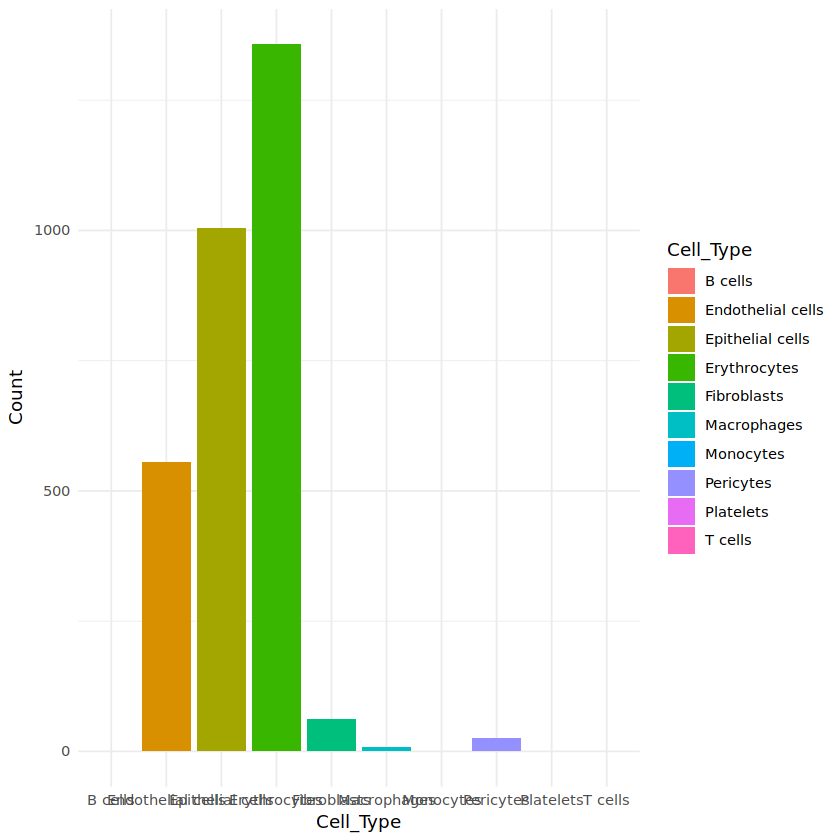

In [33]:
# make the plots # Plots the confident weights for each cell type as in full_mode (saved as # 'results/cell_type_weights_unthreshold.pdf')
plot_weights(cell_type_names, spatialRNA, resultsdir, norm_weights) 
# Plots all weights for each cell type as in full_mode. (saved as # 'results/cell_type_weights.pdf')
plot_weights_unthreshold(cell_type_names, spatialRNA, resultsdir, norm_weights) 
# Plots the weights for each cell type as in doublet_mode. (saved as # 'results/cell_type_weights_doublets.pdf')
plot_weights_doublet(cell_type_names, spatialRNA, resultsdir, results$weights_doublet, 
                     results$results_df) 
# Plots the number of confident pixels of each cell type in 'full_mode'. (saved as # 'results/cell_type_occur.pdf')
plot_cond_occur(cell_type_names, resultsdir, norm_weights, spatialRNA)